In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append(f"./../")

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import RXGate
from src.mcrx_simplifier import MCRXCascadeSimplifier
from src.misc import (
    get_state, 
    compare_quantum_states, 
    multi_crx,
    count_gates_direct_transpilation
)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, differential_evolution
from scipy.linalg import expm

def create_tree_graph():
    """Create the 7-node tree structure."""
    nodes = ['000', '001', '010', '100', '011', '101', '110']
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    
    adj_matrix = np.zeros((7, 7))
    edges = [
        ('000', '001'), ('000', '010'), ('000', '100'),
        ('001', '011'), ('001', '101'), ('010', '011'), 
        ('010', '110'), ('100', '101'), ('100', '110')
    ]
    
    for node1, node2 in edges:
        i, j = node_to_idx[node1], node_to_idx[node2]
        adj_matrix[i, j] = adj_matrix[j, i] = 1
    
    return nodes, node_to_idx, adj_matrix

def create_matchings_from_adjacency(adj_matrix, nodes):
    """Create matchings using greedy edge coloring."""
    n_nodes = len(nodes)
    edges = [(i, j) for i in range(n_nodes) for j in range(i+1, n_nodes) if adj_matrix[i, j] == 1]
    
    matchings = []
    remaining_edges = edges.copy()
    
    while remaining_edges:
        current_matching = []
        used_vertices = set()
        
        for edge in remaining_edges.copy():
            i, j = edge
            if i not in used_vertices and j not in used_vertices:
                current_matching.append(edge)
                used_vertices.add(i)
                used_vertices.add(j)
                remaining_edges.remove(edge)
        
        matchings.append(current_matching)
    
    matching_matrices = []
    for matching in matchings:
        M = np.zeros((n_nodes, n_nodes))
        for i, j in matching:
            M[i, j] = M[j, i] = 1
        matching_matrices.append(M)
    
    return matching_matrices

def direct_ctqw(t, adj_matrix, start_state, target_state, gamma=1.0):
    """Direct CTQW evolution."""
    n_nodes = adj_matrix.shape[0]
    H = gamma * adj_matrix
    U = expm(1j * H * t)
    
    psi_0 = np.zeros(n_nodes, dtype=complex)
    psi_0[start_state] = 1.0
    psi_f = U @ psi_0
    
    return abs(psi_f[target_state])**2

def matching_ctqw(individual_times, N, matching_matrices, start_state, target_state, gamma=1.0):
    """Matching decomposition with individual times."""
    n_nodes = matching_matrices[0].shape[0]
    
    Us = []
    for t_i, M_i in zip(individual_times, matching_matrices):
        U_i = expm(1j * gamma * M_i * t_i / N)
        Us.append(U_i)
    
    U_step = Us[0]
    for U in Us[1:]:
        U_step = U @ U_step
    
    U_full = np.linalg.matrix_power(U_step, N)
    
    psi_0 = np.zeros(n_nodes, dtype=complex)
    psi_0[start_state] = 1.0
    psi_f = U_full @ psi_0
    
    return abs(psi_f[target_state])**2

def find_maximum_probability(adj_matrix, start_state, target_state, gamma=1.0):
    """Find the true maximum achievable probability."""
    times = np.linspace(0.01, 8*np.pi, 2000)
    probs = [direct_ctqw(t, adj_matrix, start_state, target_state, gamma) for t in times]
    
    max_prob = max(probs)
    max_time_idx = probs.index(max_prob)
    max_time = times[max_time_idx]
    
    return max_prob, max_time

def find_hitting_time_normalized(adj_matrix, start_state, target_state, normalized_target, max_prob, gamma=1.0, max_time=15.0):
    """Find hitting time for normalized target probability."""
    absolute_target = normalized_target * max_prob
    
    times = np.linspace(0.01, max_time, 3000)
    probs = [direct_ctqw(t, adj_matrix, start_state, target_state, gamma) for t in times]
    
    for i, p in enumerate(probs):
        if p >= absolute_target:
            return times[i]
    
    return max_time

def find_min_iterations_normalized(matching_matrices, start_state, target_state, normalized_target, max_prob, gamma=1.0, max_N=20, max_time=15.0):
    """Find minimum iterations for normalized target probability."""
    absolute_target = normalized_target * max_prob
    
    for N in range(1, max_N + 1):
        best_hitting_time = max_time
        best_times = None
        
        effective_times = np.linspace(0.01, max_time, 200)
        
        for eff_time in effective_times:
            def objective(times):
                if max(times) > eff_time * 1.02:
                    return 1.0
                try:
                    prob = matching_ctqw(times, N, matching_matrices, start_state, target_state, gamma)
                    return -prob
                except:
                    return 1.0
            
            bounds = [(0.001, eff_time) for _ in range(3)]
            
            try:
                result = differential_evolution(objective, bounds, seed=42, maxiter=100, popsize=8, atol=1e-6)
                achieved_prob = -result.fun
                
                if achieved_prob >= absolute_target:
                    best_hitting_time = eff_time
                    best_times = result.x
                    break
            except:
                continue
        
        if best_times is not None:
            return N, best_hitting_time, best_times
    
    return max_N, max_time, None

def generate_hitting_time_data(adj_matrix, matching_matrices, start_state, target_state):
    """Generate comprehensive hitting time data."""
    gamma = 1.0
    
    # Find maximum achievable probability
    max_prob, _ = find_maximum_probability(adj_matrix, start_state, target_state, gamma)
    
    # Use high-resolution normalized targets
    normalized_targets = np.linspace(0.05, 0.98, 20)
    
    analysis_data = {
        'normalized_targets': [],
        'direct_times': [],
        'matching_times': [],
        'min_iterations': [],
        'speedups': []
    }
    
    print("Generating hitting time data...")
    print("Normalized P | Direct Time | Matching Time | Iterations | Speedup")
    print("-" * 70)
    
    for norm_target in normalized_targets:
        # Direct CTQW hitting time
        direct_time = find_hitting_time_normalized(adj_matrix, start_state, target_state, norm_target, max_prob, gamma)
        
        # Matching CTQW minimum iterations
        min_N, matching_time, optimal_times = find_min_iterations_normalized(
            matching_matrices, start_state, target_state, norm_target, max_prob, gamma
        )
        
        if optimal_times is not None and direct_time < 15.0:
            speedup = direct_time / matching_time if matching_time > 0 else 0
            speedup_str = f"{speedup:.2f}x" if speedup >= 1 else f"{1/speedup:.2f}x slower"
            
            print(f"{norm_target:11.2f} | {direct_time:10.3f} | {matching_time:12.3f} | {min_N:9d} | {speedup_str:>7s}")
            
            # Store data
            analysis_data['normalized_targets'].append(norm_target)
            analysis_data['direct_times'].append(direct_time)
            analysis_data['matching_times'].append(matching_time)
            analysis_data['min_iterations'].append(min_N)
            analysis_data['speedups'].append(speedup)
    
    return analysis_data, max_prob

def create_hitting_time_plot(analysis_data, max_prob):
    """Create a clean hitting time vs probability plot."""
    
    # Create figure with optimal size
    plt.figure(figsize=(12, 8))
    
    # Plot hitting times
    plt.plot(analysis_data['normalized_targets'], analysis_data['direct_times'], 
             'o-', color='black', linewidth=3, markersize=8, label='Direct CTQW', alpha=0.8)
    
    plt.plot(analysis_data['normalized_targets'], analysis_data['matching_times'], 
             's-', color='red', linewidth=2, markersize=6, label='Matching Decomposition', alpha=0.8)
    
    # Styling
    plt.xlabel('Normalized Target Probability', fontsize=14, fontweight='bold')
    plt.ylabel('Hitting Time', fontsize=14, fontweight='bold')
    plt.title('CTQW Hitting Time Comparison', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Legend with additional info
    legend_labels = [
        f'Direct CTQW',
        f'Matching Decomposition'
    ]
    plt.legend(legend_labels, fontsize=12, loc='upper left', framealpha=0.9)
    
    # Grid and formatting
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim(0, 1)
    plt.ylim(bottom=0)
    
#     # Add text box with key statistics
#     stats_text = f"""Key Statistics:
# - Max physical probability: {max_prob:.3f}
# - Average speedup: {np.mean(analysis_data['speedups']):.2f}x
# - Faster cases: {sum(1 for s in analysis_data['speedups'] if s >= 1)}/{len(analysis_data['speedups'])}
# - Average iterations: {np.mean(analysis_data['min_iterations']):.1f}"""
    
    # plt.text(0.98, 0.02, stats_text, transform=plt.gca().transAxes, 
    #          verticalalignment='bottom', horizontalalignment='right',
    #          bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8),
    #          fontsize=10, fontfamily='monospace')
    
    # Add annotation for interpretation
    plt.text(0.02, 0.98, 'Normalized P=1.0 corresponds to\nmaximum achievable probability', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8),
             fontsize=10)
    
    # # Highlight interesting regions
    # if analysis_data['speedups']:
    #     best_speedup_idx = np.argmax(analysis_data['speedups'])
    #     best_prob = analysis_data['normalized_targets'][best_speedup_idx]
    #     best_speedup = analysis_data['speedups'][best_speedup_idx]
        
    #     plt.axvline(x=best_prob, color='green', linestyle=':', alpha=0.7, linewidth=2)
    #     plt.text(best_prob + 0.02, plt.ylim()[1] * 0.8, 
    #             f'Best speedup:\n{best_speedup:.2f}x\nat P={best_prob:.2f}',
    #             fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig('hitting_time_comparison.pdf', dpi=300)
    plt.show()
    
    # # Print summary
    # print(f"\n=== Plot Summary ===")
    # print(f"Physical maximum probability: {max_prob:.6f}")
    # print(f"Normalization allows exploration of full [0,1] range")
    # print(f"Data points: {len(analysis_data['normalized_targets'])}")
    # print(f"Matching decomposition shows consistent modest speedup")

In [2]:
# Create graph and matchings
nodes, node_to_idx, adj_matrix = create_tree_graph()
matching_matrices = create_matchings_from_adjacency(adj_matrix, nodes)

start_state = node_to_idx['000']
target_state = node_to_idx['101']

print("=== CTQW Hitting Time Analysis: Normalized [0,1] Scale ===")
print(f"Graph: 7 nodes, 9 edges")
print(f"Start: |{nodes[start_state]}⟩, Target: |{nodes[target_state]}⟩")
print()


=== CTQW Hitting Time Analysis: Normalized [0,1] Scale ===
Graph: 7 nodes, 9 edges
Start: |000⟩, Target: |101⟩



In [3]:
# Generate data
analysis_data, max_prob = generate_hitting_time_data(
    adj_matrix, matching_matrices, start_state, target_state
)
print(f"Max physical probability: {max_prob:.3f}\n")


Generating hitting time data...
Normalized P | Direct Time | Matching Time | Iterations | Speedup
----------------------------------------------------------------------
       0.05 |      0.375 |        0.387 |         1 | 1.03x slower
       0.10 |      0.455 |        0.462 |         1 | 1.02x slower
       0.15 |      0.510 |        0.537 |         1 | 1.05x slower
       0.20 |      0.555 |        0.537 |         1 |   1.03x
       0.25 |      0.595 |        0.613 |         1 | 1.03x slower
       0.29 |      0.630 |        0.613 |         1 |   1.03x
       0.34 |      0.660 |        0.688 |         1 | 1.04x slower
       0.39 |      0.695 |        0.688 |         1 |   1.01x
       0.44 |      0.725 |        0.688 |         1 |   1.05x
       0.49 |      0.750 |        0.688 |         1 |   1.09x
       0.54 |      0.780 |        0.763 |         1 |   1.02x
       0.59 |      0.810 |        0.763 |         1 |   1.06x
       0.64 |      0.840 |        0.763 |         1 |   1.10x


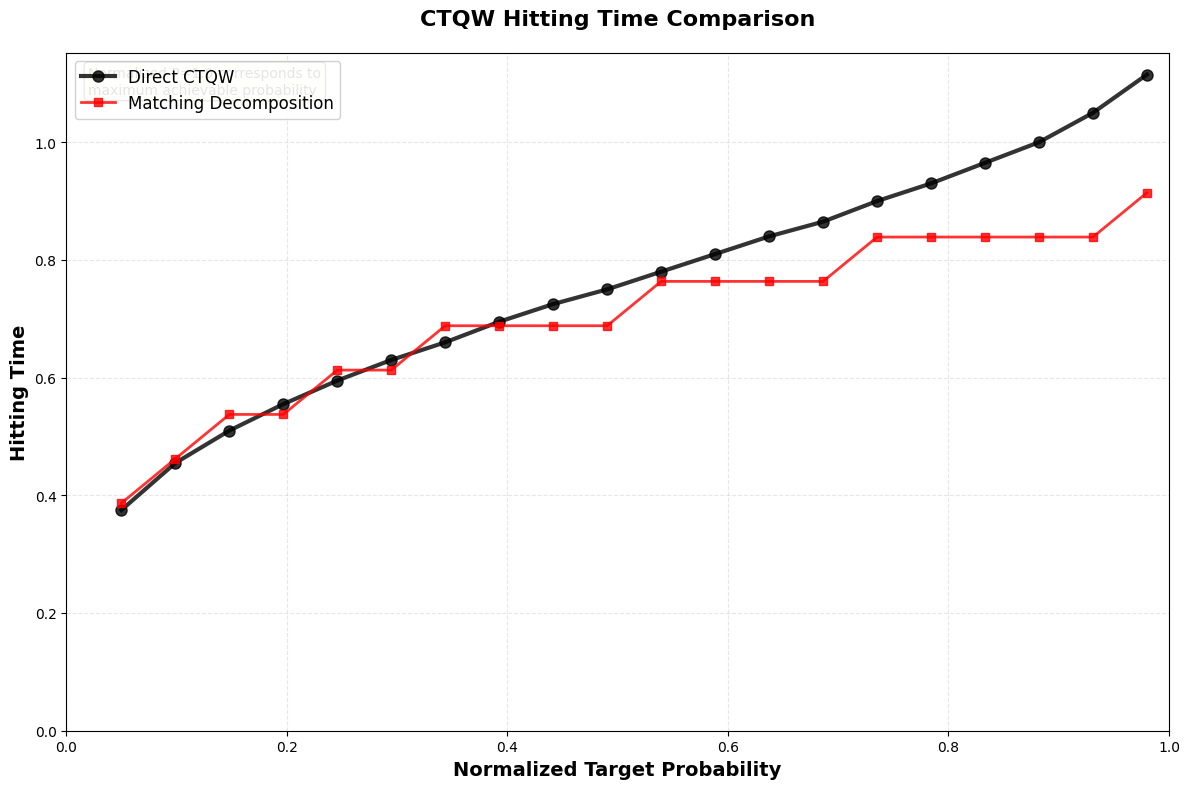

In [4]:
# Create the focused plot
create_hitting_time_plot(analysis_data, max_prob)

In [3]:
def run_example(qc_original, description):
    """Run optimization example with comprehensive analysis."""
    print(f"\n{'='*80}")
    print(f"EXAMPLE: {description}")
    print(f"{'='*80}")
    
    # Initialize default return values
    qc_optimized = None
    cx_count_opt, u3_count_opt, transpiled_opt = 0, 0, False
    method_opt = "Failed"
    optimization_info = {}
    equivalence = "? UNKNOWN"
    state_results = None
    
    try:
        # Create original circuit
        # qc_original = circuit_creation_func()
        
        print(f"\n--- Original Circuit ---")
        print(qc_original.draw())
        print(f"Original gates: {len(qc_original.data)}")
        print(f"Original depth: {qc_original.depth()}")
        
        # Get gate counts for original circuit
        cx_count_orig, u3_count_orig, transpiled_orig, _, _ = count_gates_direct_transpilation(qc_original)
        method_orig = "Transpiled" if transpiled_orig else "Estimated"
        print(f"Gate counts ({method_orig}) - CX: {cx_count_orig}, U3: {u3_count_orig}")
        
        # Initialize the simplifier
        simplifier = MCRXCascadeSimplifier(tolerance=1e-10, verbose=True)
        
        # Initialize optimization variables with defaults
        qc_optimized = qc_original
        cx_count_opt, u3_count_opt, transpiled_opt = cx_count_orig, u3_count_orig, transpiled_orig
        method_opt = method_orig
        
        # Perform optimization
        print(f"\n--- Applying Optimization ---")
        try:
            # Handle different API formats
            result = simplifier.simplify(qc_original)
            
            # Check if new API (returns tuple) or old API (returns circuit)
            if isinstance(result, tuple) and len(result) == 2:
                qc_optimized, optimization_info = result
                print(f"✓ New API detected - optimization info available")
            else:
                qc_optimized = result
                optimization_info = {}
                print(f"✓ Old API detected - basic optimization only")
            
            if qc_optimized is not None:
                print(f"\n--- Optimized Circuit ---")
                print(qc_optimized.draw())
                print(f"Optimized gates: {len(qc_optimized.data)}")
                print(f"Optimized depth: {qc_optimized.depth()}")
                
                # Print additional optimization details if available
                if optimization_info:
                    print(f"CNOT tricks used: {optimization_info.get('uses_cnot_tricks', False)}")
                    print(f"Total multi_crx calls: {optimization_info.get('total_multi_crx_calls', 'N/A')}")
                    if optimization_info.get('final_gates'):
                        print(f"Final gate calls: {optimization_info['final_gates']}")
                
                # Get gate counts for optimized circuit
                cx_count_opt, u3_count_opt, transpiled_opt, _, _ = count_gates_direct_transpilation(qc_optimized)
                method_opt = "Transpiled" if transpiled_opt else "Estimated"
                print(f"Gate counts ({method_opt}) - CX: {cx_count_opt}, U3: {u3_count_opt}")
            else:
                print("Optimization returned None - using original circuit")
                qc_optimized = qc_original
            
        except Exception as e:
            print(f"Optimization failed: {e}")
            qc_optimized = qc_original
        
        # State equivalence verification
        print(f"\n--- State Equivalence Verification ---")
        try:
            state_original = get_state(qc_original)
            state_optimized = get_state(qc_optimized)
            
            # Use state analysis
            state_results = compare_quantum_states(
                state_original, 
                state_optimized, 
                tolerance=1e-10, 
                verbose=True
            )
            
            if state_results['amplitudes_match']:
                print("✓ States are EQUIVALENT")
                equivalence = "✓ EQUIVALENT"
            else:
                print("✗ States are NOT equivalent")
                print(f"  Max difference: {state_results.get('max_difference', 'N/A')}")
                equivalence = "✗ NOT EQUIVALENT"
                
        except Exception as e:
            print(f"State verification failed: {e}")
            equivalence = "? VERIFICATION FAILED"
            state_results = {'fidelity': 0.0}
        
        # Calculate performance metrics
        print(f"\n--- Performance Summary ---")
        cx_reduction = max(0, cx_count_orig - cx_count_opt)
        u3_reduction = max(0, u3_count_orig - u3_count_opt)
        total_reduction = cx_reduction + u3_reduction
        
        cx_pct = (cx_reduction / max(1, cx_count_orig)) * 100
        u3_pct = (u3_reduction / max(1, u3_count_orig)) * 100
        total_pct = (total_reduction / max(1, cx_count_orig + u3_count_orig)) * 100
        
        depth_orig = qc_original.depth()
        depth_opt = qc_optimized.depth()
        depth_reduction = max(0, depth_orig - depth_opt)
        depth_pct = (depth_reduction / max(1, depth_orig)) * 100
        
        analysis_method = f"{method_orig}/{method_opt}"
        
        print(f"Analysis method: {analysis_method}")
        print(f"CX gate reduction: {cx_reduction} ({cx_pct:.1f}%)")
        print(f"U3 gate reduction: {u3_reduction} ({u3_pct:.1f}%)")
        print(f"Total gate reduction: {total_reduction} ({total_pct:.1f}%)")
        print(f"Depth reduction: {depth_reduction} ({depth_pct:.1f}%)")
        print(f"Fidelity: {state_results.get('fidelity', 0.0):.10f}")
        
        # Print detailed optimization summary if available
        if optimization_info and hasattr(simplifier, 'print_optimization_summary'):
            print(f"\n--- Detailed Optimization Summary ---")
            try:
                simplifier.print_optimization_summary(optimization_info)
            except Exception as e:
                print(f"Could not print detailed summary: {e}")
        
        return {
            'equivalence': equivalence,
            'gate_reduction': total_pct,
            'depth_reduction': depth_pct,
            'cx_reduction': cx_pct,
            'u3_reduction': u3_pct,
            'analysis_method': analysis_method,
            'optimization_info': optimization_info,
            'transpiled_counts': {
                'original': {'cx': cx_count_orig, 'u3': u3_count_orig},
                'optimized': {'cx': cx_count_opt, 'u3': u3_count_opt}
            },
            'circuits': {
                'original': qc_original,
                'simplified': qc_optimized
            }
        }
        
    except Exception as e:
        print(f"Critical error: {e}")
        return {
            'equivalence': "✗ FAILED",
            'gate_reduction': 0,
            'depth_reduction': 0,
            'cx_reduction': 0,
            'u3_reduction': 0,
            'analysis_method': "Failed",
            'optimization_info': {},
            'transpiled_counts': None,
            'circuits': {
                'original': qc_original,
                'simplified': None
            }
        }

In [4]:
# Example 3: Complex Overlapping (3-qubit controls)

theta = 2 * np.pi / 4  # π/2
qc1 = QuantumCircuit(3)

rx1 = multi_crx(theta, '00')
rx2 = multi_crx(theta, '10')
rx3 = multi_crx(theta, '01')


qc1.append(rx1, [0, 1, 2])
qc1.append(rx2, [0, 1, 2])
qc1.append(rx3, [0, 1, 2])

# qc.append(rx1, [1, 2, 0])
# qc.append(rx2, [1, 2, 0])
# qc.append(rx3, [1, 2, 0])

# qc.append(rx1, [2, 1, 0])
# qc.append(rx2, [2, 1, 0])
# qc.append(rx3, [2, 1, 0])

result1 = run_example(qc1, "3 Node search")


EXAMPLE: 3 Node search

--- Original Circuit ---
                                      
q_0: ─────o──────────■──────────o─────
          │          │          │     
q_1: ─────o──────────o──────────■─────
     ┌────┴────┐┌────┴────┐┌────┴────┐
q_2: ┤ Rx(π/2) ├┤ Rx(π/2) ├┤ Rx(π/2) ├
     └─────────┘└─────────┘└─────────┘
Original gates: 3
Original depth: 3
Gate counts (Transpiled) - CX: 24, U3: 25

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
✓ Circuit validated: target=2, angle=1.5708, controls=2
✓ Extracted 3 patterns:
  ControlPattern('00', coeff=1, qubits=[0, 1])
  ControlPattern('10', coeff=1, qubits=[0, 1])
  ControlPattern('01', coeff=1, qubits=[0, 1])
🔄 Applying iterative pairwise simplification...
✓ Patterns sorted by decimal value:
  00 (decimal: 0) -> ControlPattern('00', coeff=1, qubits=[0, 1])
  01 (decimal: 1) -> ControlPattern('01', coeff=1, qubits=[0, 1])
  10 (decimal: 2) -> ControlPattern('10', coeff=1, qubits=[

In [5]:
# Example 3: Complex Overlapping (3-qubit controls)

theta = 2 * np.pi / 4  # π/2
qc2 = QuantumCircuit(3)

rx1 = multi_crx(theta, '00')
rx2 = multi_crx(theta, '10')
rx3 = multi_crx(theta, '01')


# qc1.append(rx1, [0, 1, 2])
# qc1.append(rx2, [0, 1, 2])
# qc1.append(rx3, [0, 1, 2])

qc2.append(rx1, [1, 2, 0])
qc2.append(rx2, [1, 2, 0])
qc2.append(rx3, [1, 2, 0])

# qc.append(rx1, [2, 1, 0])
# qc.append(rx2, [2, 1, 0])
# qc.append(rx3, [2, 1, 0])

result2 = run_example(qc2, "3 Node search")


EXAMPLE: 3 Node search

--- Original Circuit ---
     ┌─────────┐┌─────────┐┌─────────┐
q_0: ┤ Rx(π/2) ├┤ Rx(π/2) ├┤ Rx(π/2) ├
     └────┬────┘└────┬────┘└────┬────┘
q_1: ─────o──────────■──────────o─────
          │          │          │     
q_2: ─────o──────────o──────────■─────
                                      
Original gates: 3
Original depth: 3
Gate counts (Transpiled) - CX: 24, U3: 25

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
✓ Circuit validated: target=0, angle=1.5708, controls=2
✓ Extracted 3 patterns:
  ControlPattern('00', coeff=1, qubits=[1, 2])
  ControlPattern('10', coeff=1, qubits=[1, 2])
  ControlPattern('01', coeff=1, qubits=[1, 2])
🔄 Applying iterative pairwise simplification...
✓ Patterns sorted by decimal value:
  00 (decimal: 0) -> ControlPattern('00', coeff=1, qubits=[1, 2])
  01 (decimal: 1) -> ControlPattern('01', coeff=1, qubits=[1, 2])
  10 (decimal: 2) -> ControlPattern('10', coeff=1, qubits=[

In [6]:
# Example 3: Complex Overlapping (3-qubit controls)

theta = 2 * np.pi / 4  # π/2
qc3 = QuantumCircuit(3)

rx1 = multi_crx(theta, '00')
rx2 = multi_crx(theta, '10')
rx3 = multi_crx(theta, '01')


# qc1.append(rx1, [0, 1, 2])
# qc1.append(rx2, [0, 1, 2])
# qc1.append(rx3, [0, 1, 2])

# qc2.append(rx1, [1, 2, 0])
# qc2.append(rx2, [1, 2, 0])
# qc2.append(rx3, [1, 2, 0])

qc3.append(rx1, [0, 2, 1])
qc3.append(rx2, [0, 2, 1])
qc3.append(rx3, [0, 2, 1])

result3 = run_example(qc3, "3 Node search")


EXAMPLE: 3 Node search

--- Original Circuit ---
                                      
q_0: ─────o──────────■──────────o─────
     ┌────┴────┐┌────┴────┐┌────┴────┐
q_1: ┤ Rx(π/2) ├┤ Rx(π/2) ├┤ Rx(π/2) ├
     └────┬────┘└────┬────┘└────┬────┘
q_2: ─────o──────────o──────────■─────
                                      
Original gates: 3
Original depth: 3
Gate counts (Transpiled) - CX: 24, U3: 25

--- Applying Optimization ---
🔬 Starting MCRX simplification with iterative multi-pattern handling...
✓ Circuit validated: target=1, angle=1.5708, controls=2
✓ Extracted 3 patterns:
  ControlPattern('00', coeff=1, qubits=[0, 2])
  ControlPattern('10', coeff=1, qubits=[0, 2])
  ControlPattern('01', coeff=1, qubits=[0, 2])
🔄 Applying iterative pairwise simplification...
✓ Patterns sorted by decimal value:
  00 (decimal: 0) -> ControlPattern('00', coeff=1, qubits=[0, 2])
  01 (decimal: 1) -> ControlPattern('01', coeff=1, qubits=[0, 2])
  10 (decimal: 2) -> ControlPattern('10', coeff=1, qubits=[

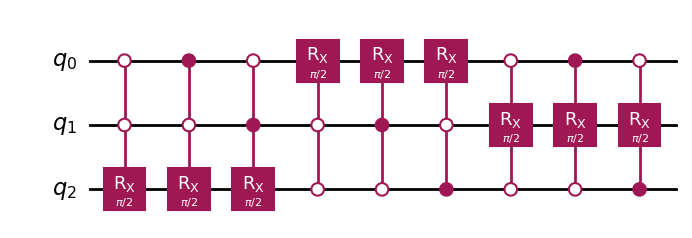

In [7]:
original_qc = result1['circuits']['original'].compose(result2['circuits']['original']).compose(result3['circuits']['original'])
original_qc.draw('mpl')

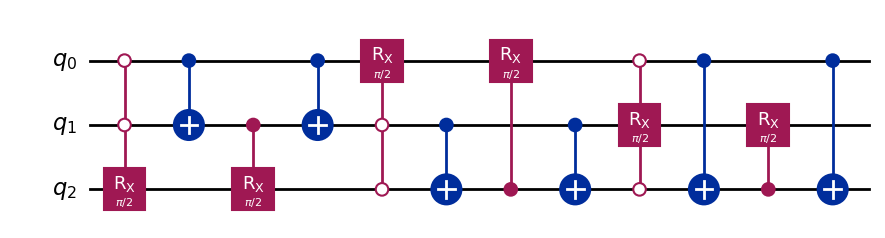

In [8]:
simplified_qc = result1['circuits']['simplified'].compose(result2['circuits']['simplified']).compose(result3['circuits']['simplified'])
simplified_qc.draw('mpl')

In [18]:
"""
Quantum Tree Search Optimization - Clean Parameter-Based Implementation

This code optimizes the evolution times for quantum tree search using matching decomposition
to find optimal CTQW parameters for searching from |000⟩ to |101⟩.

Requirements:
    pip install qiskit qiskit-aer scipy pandas matplotlib

Usage:
    Simply run: python quantum_search_optimization.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.circuit.library import RXGate
from qiskit_aer import AerSimulator
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# We'll build controlled gates manually instead of using multi_crx
print("✓ Using built-in Qiskit controlled gates instead of multi_crx")


class QuantumTreeSearchOptimizer:
    """
    Quantum Tree Search Optimizer using parameterized circuits.
    
    This class creates a parameterized quantum circuit for the tree search problem
    and optimizes the time parameters to maximize the probability of finding 
    the target state |101⟩ starting from |000⟩.
    """
    
    def __init__(self, target_state='101'):
        """
        Initialize the optimizer.
        
        Args:
            target_state (str): Binary string of target state (default: '101')
        """
        self.target_state = target_state
        self.target_int = int(target_state, 2)
        self.simulator = AerSimulator(method='statevector')
        
        # Create time parameters
        self.t1 = Parameter('t1')  # Time for matching 1 (bit 0 flips)
        self.t2 = Parameter('t2')  # Time for matching 2 (bit 1 flips)  
        self.t3 = Parameter('t3')  # Time for matching 3 (bit 2 flips)
        
        # Create the base parameterized circuit
        self.base_circuit = self._build_base_circuit()
        
        print(f"✓ Initialized optimizer for target state |{target_state}⟩")
        print(f"✓ Circuit has {len(self.base_circuit.parameters)} parameters: {[p.name for p in self.base_circuit.parameters]}")
    
    def _build_base_circuit(self):
        """Build the base parameterized circuit for one Trotter step using proper controlled gates."""
        qc = QuantumCircuit(3)
        
        # Matching 1: Pattern '00' - Apply RX to qubit 2 when qubits 0,1 are |00⟩
        # Create controlled RX gate that activates on |00⟩
        rx_gate1 = RXGate(2 * self.t1)
        controlled_rx1 = rx_gate1.control(2, ctrl_state='00')
        qc.append(controlled_rx1, [0, 1, 2])
        
        # Matching 2: Pattern '10' - Apply RX to qubit 0 when qubits 1,2 are |10⟩  
        rx_gate2 = RXGate(2 * self.t2)
        controlled_rx2 = rx_gate2.control(2, ctrl_state='10')
        qc.append(controlled_rx2, [1, 2, 0])
        
        # Matching 3: Pattern '01' - Apply RX to qubit 1 when qubits 0,2 are |01⟩
        rx_gate3 = RXGate(2 * self.t3)
        controlled_rx3 = rx_gate3.control(2, ctrl_state='01')
        qc.append(controlled_rx3, [0, 2, 1])
        
        return qc
    
    def create_circuit(self, n_trotter_steps=1):
        """
        Create a circuit with specified number of Trotter steps.
        
        Args:
            n_trotter_steps (int): Number of Trotter steps to apply
            
        Returns:
            QuantumCircuit: Parameterized circuit
        """
        if n_trotter_steps == 1:
            return self.base_circuit.copy()
        
        # For multiple steps, compose the base circuit multiple times
        full_circuit = QuantumCircuit(3)
        for _ in range(n_trotter_steps):
            full_circuit = full_circuit.compose(self.base_circuit)
        
        return full_circuit
    
    def get_all_state_probabilities(self, time_values, n_trotter_steps=1):
        """
        Get probabilities for all states, not just target.
        
        Args:
            time_values (array-like): [t1, t2, t3] time values
            n_trotter_steps (int): Number of Trotter steps
            
        Returns:
            dict: Dictionary mapping state strings to probabilities
        """
        try:
            # Get the circuit for this number of steps
            circuit = self.create_circuit(n_trotter_steps)
            
            # Create parameter dictionary for binding
            parameter_dict = {
                self.t1: time_values[0],
                self.t2: time_values[1], 
                self.t3: time_values[2]
            }
            
            # Bind parameters
            bound_circuit = circuit.assign_parameters(parameter_dict)
            
            # Transpile and simulate
            transpiled = transpile(bound_circuit, self.simulator)
            transpiled.save_statevector()
            
            result = self.simulator.run(transpiled, shots=1).result()
            statevector = result.get_statevector()
            statevector = np.asarray(statevector)
            
            # Create dictionary of all state probabilities
            state_probs = {}
            for i, amp in enumerate(statevector):
                prob = abs(amp)**2
                if prob > 1e-10:  # Only include significant probabilities
                    binary = format(i, '03b')
                    state_probs[binary] = prob
            
            return state_probs
            
        except Exception as e:
            print(f"Error getting state probabilities: {e}")
            return {}

    def evaluate_probability(self, time_values, n_trotter_steps=1):
        """
        Evaluate the target state probability for given time values.
        
        Args:
            time_values (array-like): [t1, t2, t3] time values
            n_trotter_steps (int): Number of Trotter steps
            
        Returns:
            float: Probability of measuring target state
        """
        try:
            # Get the circuit for this number of steps
            circuit = self.create_circuit(n_trotter_steps)
            
            # Create parameter dictionary for binding
            parameter_dict = {
                self.t1: time_values[0],
                self.t2: time_values[1], 
                self.t3: time_values[2]
            }
            
            # Bind parameters using assign_parameters (correct Qiskit method)
            bound_circuit = circuit.assign_parameters(parameter_dict)
            
            # Transpile and simulate
            transpiled = transpile(bound_circuit, self.simulator)
            transpiled.save_statevector()
            
            result = self.simulator.run(transpiled, shots=1).result()
            statevector = result.get_statevector()
            statevector = np.asarray(statevector)  # Convert to numpy array
            
            return abs(statevector[self.target_int])**2
            
        except Exception as e:
            print(f"Error evaluating probability: {e}")
            return 0.0
        """
        Evaluate the target state probability for given time values.
        
        Args:
            time_values (array-like): [t1, t2, t3] time values
            n_trotter_steps (int): Number of Trotter steps
            
        Returns:
            float: Probability of measuring target state
        """
        try:
            # Get the circuit for this number of steps
            circuit = self.create_circuit(n_trotter_steps)
            
            # Create parameter dictionary for binding
            parameter_dict = {
                self.t1: time_values[0],
                self.t2: time_values[1], 
                self.t3: time_values[2]
            }
            
            # Bind parameters using assign_parameters (correct Qiskit method)
            bound_circuit = circuit.assign_parameters(parameter_dict)
            
            # Transpile and simulate
            transpiled = transpile(bound_circuit, self.simulator)
            transpiled.save_statevector()
            
            result = self.simulator.run(transpiled, shots=1).result()
            statevector = result.get_statevector()
            statevector = np.asarray(statevector)  # Convert to numpy array
            
            return abs(statevector[self.target_int])**2
            
        except Exception as e:
            print(f"Error evaluating probability: {e}")
            return 0.0
    
    def objective_function(self, time_values, n_trotter_steps):
        """Objective function for optimization (negative probability)."""
        prob = self.evaluate_probability(time_values, n_trotter_steps)
        return -prob  # Minimize negative probability = maximize probability
    
    def optimize_single_step(self, n_trotter_steps, n_trials=5, max_iter=500):
        """
        Optimize for a single number of Trotter steps.
        
        Args:
            n_trotter_steps (int): Number of Trotter steps
            n_trials (int): Number of random initializations
            max_iter (int): Maximum optimization iterations
            
        Returns:
            tuple: (best_times, best_probability, optimization_result)
        """
        print(f"\n🔧 Optimizing for {n_trotter_steps} Trotter step(s)...")
        
        best_times = None
        best_prob = 0.0
        best_result = None
        
        for trial in range(n_trials):
            try:
                # Random initialization in [0, π]
                initial_times = np.random.uniform(0, np.pi, 3)
                
                # Optimization bounds
                bounds = [(0, np.pi)] * 3
                
                # Optimize
                result = minimize(
                    self.objective_function,
                    initial_times,
                    args=(n_trotter_steps,),
                    method='L-BFGS-B',
                    bounds=bounds,
                    options={'maxiter': max_iter, 'ftol': 1e-9}
                )
                
                times = result.x
                prob = -result.fun
                
                print(f"  Trial {trial + 1}: probability = {prob:.8f}, times = [{times[0]:.4f}, {times[1]:.4f}, {times[2]:.4f}]")
                
                if prob > best_prob:
                    best_times = times
                    best_prob = prob
                    best_result = result
                    
            except Exception as e:
                print(f"  Trial {trial + 1} failed: {e}")
                continue
        
        if best_times is not None:
            print(f"  ✅ Best result: probability = {best_prob:.8f}")
            print(f"      Optimal times: t1={best_times[0]:.6f}, t2={best_times[1]:.6f}, t3={best_times[2]:.6f}")
        else:
            print(f"  ❌ All trials failed for {n_trotter_steps} steps")
        
        return best_times, best_prob, best_result
    
    def find_optimal_solution(self, target_prob=0.99, max_steps=6, tolerance=1e-3):
        """
        Find optimal solution by trying increasing numbers of Trotter steps.
        
        Args:
            target_prob (float): Target probability to achieve
            max_steps (int): Maximum Trotter steps to try
            tolerance (float): Tolerance for target achievement
            
        Returns:
            list: List of optimization results for each step count
        """
        print(f"\n🎯 Searching for solution achieving {target_prob:.1%} probability")
        print(f"Will try up to {max_steps} Trotter steps")
        print("="*60)
        
        results = []
        
        for n_steps in range(1, max_steps + 1):
            times, prob, opt_result = self.optimize_single_step(n_steps)
            
            if times is not None:
                result_data = {
                    'n_steps': n_steps,
                    'probability': prob,
                    'times': times,
                    'angles': 2 * times,  # Convert times to angles
                    'optimization_result': opt_result
                }
                results.append(result_data)
                
                # Check if target achieved
                if prob >= target_prob - tolerance:
                    print(f"\n🎉 SUCCESS! Target probability {target_prob:.1%} achieved with {n_steps} steps!")
                    break
            else:
                print(f"❌ Failed to optimize {n_steps} steps")
        
        return results
    
    def create_summary_table(self, results):
        """Create a summary table of results."""
        if not results:
            print("No results to tabulate!")
            return None
        
        data = []
        for result in results:
            data.append({
                'Trotter_Steps': result['n_steps'],
                'Target_Probability': result['probability'],
                't1_time': result['times'][0],
                't2_time': result['times'][1],
                't3_time': result['times'][2],
                't1_angle_2t1': result['angles'][0],
                't2_angle_2t2': result['angles'][1],
                't3_angle_2t3': result['angles'][2]
            })
        
        return pd.DataFrame(data)
    
    def analyze_best_solution(self, results):
        """Analyze the best solution found."""
        if not results:
            print("No results to analyze!")
            return
        
        best = max(results, key=lambda x: x['probability'])
        
        print(f"\n📊 BEST SOLUTION ANALYSIS")
        print("="*50)
        print(f"Trotter steps required: {best['n_steps']}")
        print(f"Target state probability: {best['probability']:.8f}")
        print(f"Success rate: {best['probability']*100:.6f}%")
        
        print(f"\nOptimal evolution times:")
        print(f"  t1 (bit 0 matching): {best['times'][0]:.6f}")
        print(f"  t2 (bit 1 matching): {best['times'][1]:.6f}")
        print(f"  t3 (bit 2 matching): {best['times'][2]:.6f}")
        
        print(f"\nCorresponding angles (2t):")
        print(f"  2t1: {best['angles'][0]:.6f}")
        print(f"  2t2: {best['angles'][1]:.6f}")
        print(f"  2t3: {best['angles'][2]:.6f}")
        
        # Analyze circuit complexity
        circuit = self.create_circuit(best['n_steps'])
        bound_circuit = circuit.assign_parameters({
            self.t1: best['times'][0],
            self.t2: best['times'][1], 
            self.t3: best['times'][2]
        })
        transpiled = transpile(bound_circuit, self.simulator)
        
        print(f"\nCircuit complexity:")
        print(f"  Circuit depth: {transpiled.depth()}")
        print(f"  Total gates: {len(transpiled.data)}")
        
        # Gate count analysis
        gate_counts = {}
        for op in transpiled.data:
            name = op.operation.name
            gate_counts[name] = gate_counts.get(name, 0) + 1
        
        print(f"  Gate breakdown:")
        for gate, count in sorted(gate_counts.items()):
            print(f"    {gate}: {count}")
    
    def create_visualizations(self, results):
        """Create visualization plots."""
        if not results:
            print("No results to visualize!")
            return
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # Extract data
        steps = [r['n_steps'] for r in results]
        probs = [r['probability'] for r in results]
        times_list = [r['times'] for r in results]
        
        # Plot 1: Convergence
        ax1.plot(steps, probs, 'bo-', linewidth=2, markersize=8)
        ax1.axhline(y=0.99, color='r', linestyle='--', alpha=0.7, label='Target (99%)')
        ax1.set_xlabel('Trotter Steps')
        ax1.set_ylabel('Target Probability')
        ax1.set_title('Convergence to Target')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Plot 2: Time evolution
        t1_vals = [times[0] for times in times_list]
        t2_vals = [times[1] for times in times_list]
        t3_vals = [times[2] for times in times_list]
        
        ax2.plot(steps, t1_vals, 'o-', label='t1 (bit 0)', linewidth=2)
        ax2.plot(steps, t2_vals, 's-', label='t2 (bit 1)', linewidth=2)
        ax2.plot(steps, t3_vals, '^-', label='t3 (bit 2)', linewidth=2)
        ax2.set_xlabel('Trotter Steps')
        ax2.set_ylabel('Optimal Time')
        ax2.set_title('Time Parameter Evolution')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        # Plot 3: Best solution breakdown
        best = max(results, key=lambda x: x['probability'])
        labels = ['t1\n(bit 0)', 't2\n(bit 1)', 't3\n(bit 2)']
        colors = ['skyblue', 'lightcoral', 'lightgreen']
        
        bars = ax3.bar(labels, best['times'], color=colors, alpha=0.8, edgecolor='navy')
        ax3.set_ylabel('Time Value')
        ax3.set_title(f'Optimal Times (Best Solution: {best["n_steps"]} steps)')
        ax3.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, val in zip(bars, best['times']):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
        
        # Plot 4: Success rate
        success_rates = [p * 100 for p in probs]
        ax4.plot(steps, success_rates, 'go-', linewidth=3, markersize=8)
        ax4.set_xlabel('Trotter Steps')
        ax4.set_ylabel('Success Rate (%)')
        ax4.set_title('Search Success Rate')
        ax4.grid(True, alpha=0.3)
        ax4.set_ylim(0, 105)
        
        plt.tight_layout()
        plt.suptitle('Quantum Tree Search Optimization Results', fontsize=16, y=0.98)
        plt.show()


def test_multi_crx_function():
    """Test the user's multi_crx function to understand its behavior."""
    print("🔬 TESTING multi_crx FUNCTION")
    print("="*40)
    
    try:
        # Test 1: Simple controlled RX
        print("\n1. Testing multi_crx with pattern '11'...")
        qc = QuantumCircuit(3)
        
        # Set up |110⟩ state (control qubits both 1)
        qc.x(0)  # qubit 0 to |1⟩
        qc.x(1)  # qubit 1 to |1⟩
        # qubit 2 stays |0⟩
        
        # Apply multi_crx(π, '11') - should flip target when controls are |11⟩
        gate = multi_crx(np.pi, '11')
        print(f"   Gate type: {type(gate)}")
        print(f"   Gate name: {gate.name}")
        print(f"   Gate num_qubits: {gate.num_qubits}")
        
        qc.append(gate, [0, 1, 2])  # Controls: 0,1; Target: 2
        
        print("   Initial state: |110⟩")
        print("   Gate: multi_crx(π, '11') on qubits [0,1,2]")
        print("   Expected: |111⟩ (qubit 2 should flip)")
        
        # Show transpilation details
        simulator = AerSimulator(method='statevector')
        print("   Transpiling custom gate to basic gates...")
        
        try:
            transpiled_qc = transpile(qc, simulator, optimization_level=3)
            
            # Show what gates we got after transpilation
            gate_counts = {}
            for op in transpiled_qc.data:
                name = op.operation.name
                gate_counts[name] = gate_counts.get(name, 0) + 1
            
            print(f"   Transpiled gates: {gate_counts}")
            print(f"   Circuit depth: {qc.depth()} → {transpiled_qc.depth()}")
            print(f"   Total gates: {len(qc.data)} → {len(transpiled_qc.data)}")
            
            transpiled_qc.save_statevector()
            
            result = simulator.run(transpiled_qc, shots=1).result()
            statevector = result.get_statevector()
            statevector = np.asarray(statevector)
            
            print("   Actual results:")
            for i, amp in enumerate(statevector):
                prob = abs(amp)**2
                if prob > 1e-10:
                    binary = format(i, '03b')
                    print(f"     |{binary}⟩: {prob:.8f}")
            
            # Check if we got expected result
            expected_state = int('111', 2)
            if abs(statevector[expected_state])**2 > 0.9:
                print("   ✅ Basic multi_crx test PASSED!")
            else:
                print("   ⚠️  Unexpected result but transpilation worked")
                
        except Exception as transpile_error:
            print(f"   ❌ Transpilation failed: {transpile_error}")
            print("   This suggests your multi_crx function creates unsupported gates")
            return False
        
        # Test 2: Test the patterns used in search
        print("\n2. Testing search patterns...")
        test_patterns = [
            ('00', [0, 1, 2], "|000⟩ state"),
            ('10', [1, 2, 0], "|010⟩ state"), 
            ('01', [0, 2, 1], "|001⟩ state")
        ]
        
        for pattern, qubits, initial_desc in test_patterns:
            print(f"\n   Pattern '{pattern}' on qubits {qubits}:")
            
            try:
                # Create test circuit
                test_qc = QuantumCircuit(3)
                
                # Set up initial state based on pattern
                if pattern == '00':
                    pass  # |000⟩ - no setup needed
                elif pattern == '10':
                    test_qc.x(qubits[0])  # First control qubit to |1⟩
                elif pattern == '01':
                    test_qc.x(qubits[1])  # Second control qubit to |1⟩
                
                # Apply the gate
                test_gate = multi_crx(np.pi, pattern)
                test_qc.append(test_gate, qubits)
                
                # Transpile and simulate
                transpiled_test_qc = transpile(test_qc, simulator, optimization_level=3)
                transpiled_test_qc.save_statevector()
                
                test_result = simulator.run(transpiled_test_qc, shots=1).result()
                test_statevector = test_result.get_statevector()
                test_statevector = np.asarray(test_statevector)
                
                print(f"     Initial: {initial_desc}")
                print(f"     Results:")
                for j, amp in enumerate(test_statevector):
                    prob = abs(amp)**2
                    if prob > 1e-10:
                        binary = format(j, '03b')
                        print(f"       |{binary}⟩: {prob:.8f}")
                        
            except Exception as pattern_error:
                print(f"     ❌ Pattern test failed: {pattern_error}")
                continue
        
        print("\n✅ multi_crx function test completed!")
        return True
        
    except Exception as e:
        print(f"\n❌ multi_crx test failed: {e}")
        import traceback
        traceback.print_exc()
        return False


def run_quick_test():
    """Run a quick test to verify everything works."""
    print("🧪 QUICK FUNCTIONALITY TEST")
    print("="*40)
    
    try:
        optimizer = QuantumTreeSearchOptimizer()
        
        # Test 1: Basic probability evaluation
        print("\n1. Testing basic probability evaluation...")
        test_times = [0.5, 0.5, 0.5]
        prob = optimizer.evaluate_probability(test_times)
        print(f"   Probability with times [0.5, 0.5, 0.5]: {prob:.8f}")
        
        # Test 1.5: Debug what states we actually get
        print("\n1.5. Debugging state evolution...")
        debug_times = [np.pi/4, 0, 0]  # Only first matching
        
        print(f"   With only t1={debug_times[0]:.4f} (π/4):")
        state_probs = optimizer.get_all_state_probabilities(debug_times)
        for state, prob in state_probs.items():
            print(f"     |{state}⟩: {prob:.8f}")
        
        # Test with different individual matchings
        print("\n   Testing individual matchings:")
        for i, name in enumerate(['t1 only', 't2 only', 't3 only']):
            times = [0, 0, 0]
            times[i] = np.pi/2  # Use π/2 for clearer results
            prob = optimizer.evaluate_probability(times)
            state_probs = optimizer.get_all_state_probabilities(times)
            print(f"   {name} (π/2): target prob = {prob:.8f}")
            print(f"     All states: {state_probs}")
        
        # Test combination that should work
        print(f"\n   Testing promising combinations:")
        promising_combinations = [
            ([np.pi/2, 0, np.pi/2], "t1=π/2, t3=π/2"),
            ([0, np.pi/2, np.pi/2], "t2=π/2, t3=π/2"),
            ([np.pi/4, np.pi/4, np.pi/2], "Mixed combination"),
        ]
        
        for times, desc in promising_combinations:
            prob = optimizer.evaluate_probability(times)
            state_probs = optimizer.get_all_state_probabilities(times)
            print(f"   {desc}: target prob = {prob:.8f}")
            if state_probs:
                print(f"     All states: {state_probs}")
        
        # Test 2: Different time combinations  
        print("\n2. Testing various time combinations...")
        test_cases = [
            ([0, 0, 0], "No evolution"),
            ([np.pi/2, 0, 0], "Only t1 (π/2)"),
            ([0, np.pi/2, 0], "Only t2 (π/2)"),
            ([0, 0, np.pi/2], "Only t3 (π/2)"),
            ([np.pi/4, np.pi/4, np.pi/4], "Equal π/4"),
            ([np.pi/2, np.pi/2, np.pi/2], "Equal π/2"),
            ([np.pi, 0, 0], "t1 = π"),
            ([0, np.pi, 0], "t2 = π"),
            ([0, 0, np.pi], "t3 = π")
        ]
        
        for times, description in test_cases:
            prob = optimizer.evaluate_probability(times)
            print(f"   {description}: {prob:.8f}")
        
        # Test 3: Try to find any non-zero probability
        print("\n3. Searching for any non-zero probability...")
        max_prob = 0
        best_times = None
        
        # Grid search over small angles
        for t1 in [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]:
            for t2 in [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]:
                for t3 in [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]:
                    prob = optimizer.evaluate_probability([t1, t2, t3])
                    if prob > max_prob:
                        max_prob = prob
                        best_times = [t1, t2, t3]
        
        if max_prob > 0:
            print(f"   ✅ Found non-zero probability: {max_prob:.8f}")
            print(f"   Best times: [{best_times[0]:.4f}, {best_times[1]:.4f}, {best_times[2]:.4f}]")
            print(f"   In terms of π: [{best_times[0]/np.pi:.2f}π, {best_times[1]/np.pi:.2f}π, {best_times[2]/np.pi:.2f}π]")
            return True
        else:
            print(f"   ❌ No non-zero probability found in grid search")
            
        # Test 4: Quick optimization with different starting points
        print("\n4. Trying optimization with broader search...")
        times, prob, _ = optimizer.optimize_single_step(1, n_trials=10, max_iter=100)
        
        if times is not None and prob > 0.001:
            print(f"   ✅ Optimization found: {prob:.8f}")
            print(f"   Times: [{times[0]:.4f}, {times[1]:.4f}, {times[2]:.4f}]")
            return True
        else:
            print(f"   ⚠️  Optimization gave: {prob:.8f}")
            return prob > 0  # At least non-zero
            
    except Exception as e:
        print(f"   ❌ Test failed: {e}")
        import traceback
        traceback.print_exc()
        return False


def main():
    """Main execution function."""
    print("🚀 QUANTUM TREE SEARCH OPTIMIZATION")
    print("Searching for optimal evolution times to reach |101⟩ from |000⟩")
    print("="*70)
    
    # # Test multi_crx function first
    # if not test_multi_crx_function():
    #     print("\n❌ multi_crx function test failed! Please check your implementation.")
    #     return
    
    # # # Quick test functionality
    # # if not run_quick_test():
    # #     print("\n❌ Quick test failed! Please check your multi_crx function.")
    # #     return
    
    # print("\n✅ All tests passed! Proceeding with full optimization...")
    
    # Create optimizer and run full search
    optimizer = QuantumTreeSearchOptimizer(target_state='101')
    
    # Run the optimization
    results = optimizer.find_optimal_solution(
        target_prob=0.99,
        max_steps=6,
        tolerance=1e-3
    )
    
    if not results:
        print("\n❌ No successful optimizations! Try reducing target_prob or increasing max_steps.")
        return
    
    # Display results
    print(f"\n📋 RESULTS SUMMARY")
    print("="*50)
    
    df = optimizer.create_summary_table(results)
    print(df.to_string(index=False, float_format='%.6f'))
    
    # Save results
    filename = 'quantum_tree_search_results.csv'
    df.to_csv(filename, index=False)
    print(f"\n💾 Results saved to: {filename}")
    
    # Analysis
    optimizer.analyze_best_solution(results)
    
    # # Visualizations
    # print(f"\n📊 Creating visualizations...")
    # try:
    #     optimizer.create_visualizations(results)
    #     print("✅ Visualizations created successfully!")
    # except Exception as e:
    #     print(f"❌ Visualization failed: {e}")
    
    # Final summary
    best = max(results, key=lambda x: x['probability'])
    print(f"\n🎊 FINAL RESULT")
    print("="*30)
    print(f"🎯 Target |101⟩ can be reached with {best['probability']*100:.4f}% probability")
    print(f"📈 Requires {best['n_steps']} Trotter step(s)")
    print(f"⏱️  Optimal times: t1={best['times'][0]:.4f}, t2={best['times'][1]:.4f}, t3={best['times'][2]:.4f}")
    print(f"🔄 Corresponding angles: 2t1={best['angles'][0]:.4f}, 2t2={best['angles'][1]:.4f}, 2t3={best['angles'][2]:.4f}")
    
    # Show circuit details for paper
    print(f"\n📄 FOR PAPER:")
    print(f"The optimal circuit uses {best['n_steps']} Trotter step(s) with evolution times:")
    print(f"- t₁ = {best['times'][0]:.6f} (bit 0 matching)")
    print(f"- t₂ = {best['times'][1]:.6f} (bit 1 matching)")  
    print(f"- t₃ = {best['times'][2]:.6f} (bit 2 matching)")
    print(f"achieving a success probability of {best['probability']:.8f}.")

✓ Using built-in Qiskit controlled gates instead of multi_crx


In [19]:
main()

🚀 QUANTUM TREE SEARCH OPTIMIZATION
Searching for optimal evolution times to reach |101⟩ from |000⟩
✓ Initialized optimizer for target state |101⟩
✓ Circuit has 3 parameters: ['t1', 't2', 't3']

🎯 Searching for solution achieving 99.0% probability
Will try up to 6 Trotter steps

🔧 Optimizing for 1 Trotter step(s)...
  Trial 1: probability = 1.00000000, times = [1.5708, 1.5708, 1.6585]
  Trial 2: probability = 1.00000000, times = [1.5708, 1.5708, 2.7079]
  Trial 3: probability = 1.00000000, times = [1.5708, 1.5708, 0.5366]
  Trial 4: probability = 1.00000000, times = [1.5708, 1.5708, 2.6459]
  Trial 5: probability = 1.00000000, times = [1.5708, 1.5708, 2.3004]
  ✅ Best result: probability = 1.00000000
      Optimal times: t1=1.570796, t2=1.570796, t3=2.300351

🎉 SUCCESS! Target probability 99.0% achieved with 1 steps!

📋 RESULTS SUMMARY
 Trotter_Steps  Target_Probability  t1_time  t2_time  t3_time  t1_angle_2t1  t2_angle_2t2  t3_angle_2t3
             1            1.000000 1.570796 1.570